In [14]:
import matplotlib.pyplot as plt
import pandas as pd

import os

input_directory = r"E:\Users\Sebastian_van_Dijk\TEMP"
organoids = ["TL01", "TL09","TL10","TL11","TL12","TL31"]
dirs = []
for organoid in organoids:
    dir_path = os.path.join(input_directory, organoid, "properties")
    dirs.append(dir_path)

all_df = pd.DataFrame()
for organoid, directory in zip(organoids, dirs):
    for file in os.listdir(directory):
        if file.endswith(".txt"):
            df = pd.read_csv(os.path.join(directory, file), sep="\t")
            if organoid == "TL01":
                df["type"] = "WT"
            elif organoid == "TL26":
                df["type"] = "CRC"
            else:
                df["type"] = "mixed"
            df["organoid"] = organoid
            all_df = pd.concat([all_df, df], ignore_index=True)

all_df["ratioWT_CRC"] = all_df["raw_WT"] / all_df["raw_CRC"]

In [15]:
df

,label,z,y,x,bounding_box,volume,area_WT,raw_WT,area_CRC,raw_CRC,Phenotype,type,organoid
0,1,1.592878,31.710720,145.026432,"(0, 17, 121, 5, 50, 172)",2724.0,2724.0,107.593245,2724.0,139.082232,CRC,mixed,TL31
1,2,0.502924,66.688304,178.958480,"(0, 51, 162, 2, 84, 198)",1710.0,1710.0,107.840351,1710.0,147.695322,CRC,mixed,TL31
2,3,0.428212,75.352645,115.767003,"(0, 60, 105, 2, 90, 127)",794.0,794.0,108.108312,794.0,129.226700,CRC,mixed,TL31
3,4,0.500000,87.396175,198.342896,"(0, 74, 188, 2, 102, 209)",732.0,732.0,108.256831,732.0,148.155738,CRC,mixed,TL31
4,5,0.365912,100.827175,150.847437,"(0, 85, 141, 2, 117, 162)",839.0,839.0,108.052443,839.0,129.520858,CRC,mixed,TL31
...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,306,22.197531,202.190329,213.412551,"(21, 189, 203, 24, 216, 223)",972.0,972.0,107.884774,972.0,114.017490,CRC,mixed,TL31
306,307,21.000000,211.465909,138.431818,"(21, 204, 132, 22, 221, 146)",176.0,176.0,108.034091,176.0,117.556818,CRC,mixed,TL31
307,308,21.515982,220.223744,237.465753,"(21, 214, 232, 23, 227, 244)",219.0,219.0,107.214612,219.0,121.447489,CRC,mixed,TL31
308,309,22.165574,229.445902,208.193443,"(21, 221, 198, 24, 238, 218)",610.0,610.0,107.824590,610.0,117.613115,CRC,mixed,TL31


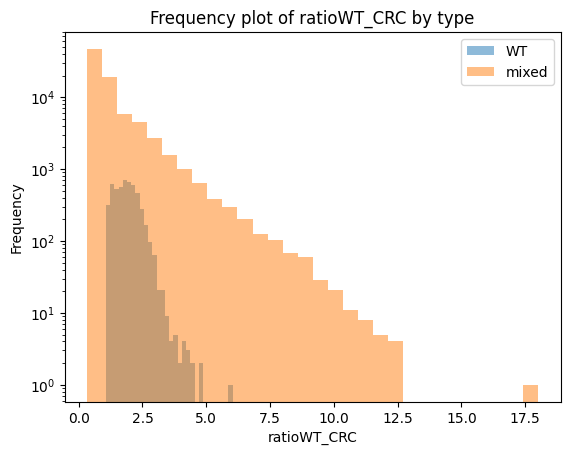

In [13]:
for t in all_df["type"].unique():
    subset = all_df[all_df["type"] == t]
    plt.hist(subset["ratioWT_CRC"], bins=30, alpha=0.5, label=t)

plt.xlabel("ratioWT_CRC")
plt.ylabel("Frequency")
plt.title("Frequency plot of ratioWT_CRC by type")
plt.yscale("log")  # Make y-axis logarithmic
plt.legend()
plt.show()

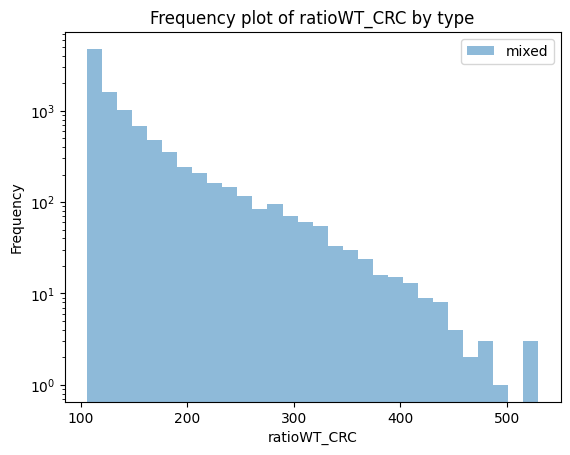

In [18]:
subset = all_df[all_df["organoid"] == "TL11"]
plt.hist(subset["raw_WT"], bins=30, alpha=0.5, label=t)

plt.xlabel("ratioWT_CRC")
plt.ylabel("Frequency")
plt.title("Frequency plot of ratioWT_CRC by type")
plt.yscale("log")  # Make y-axis logarithmic
plt.legend()
plt.show()

In [4]:
input_directory = r"E:\Users\Sebastian_van_Dijk\TEMP\TL31\frames"

import tifffile
import scipy.ndimage as ndimage
from skimage.measure import regionprops
import pandas as pd
import numpy as np
import trackpy as tp
import esda
from scipy.ndimage import zoom
import libpysal

import os

from utils.load_model import load_model
from utils.threshold import threshold
#from load_model import load_model
#from threshold import threshold
model = load_model(
    r"E:\Users\Sebastian_van_Dijk\TEMP\Train model whole organoid segmentation\smoothed_XY\models\whole_organoid_segmentation",
    )

def crop(XY_path, input_frames, model):
    original = tifffile.imread(XY_path)

    resize_factors = (1, 200 / original.shape[1] , 200 / original.shape[2])

    XY = ndimage.zoom(original, resize_factors, order=0)

    XY = ndimage.gaussian_filter(XY, sigma=(0, 2, 2))

    timepoints, y, x = XY.shape

    masks = []
    for frame in range(timepoints):
        image = XY[frame, :, :]
        mask, _, _ = model.eval(image, diameter=None, do_3D=False)
        masks.append(mask)

    XY_mask = np.stack(masks, axis=0).astype(np.uint16)

    rescale_factors = (
        1,
        original.shape[1] / XY_mask.shape[1],
        original.shape[2] / XY_mask.shape[2],
    )
    XY_mask = ndimage.zoom(masks, rescale_factors, order=0)

    features = []
    for t in range(timepoints):
        props = regionprops(XY_mask[t])
        for prop in props:
            features.append(
                {
                    "frame": t,
                    "y": prop.centroid[0],
                    "x": prop.centroid[1],
                    "label": prop.label,
                }
            )
    features_df = pd.DataFrame(features)

    linked = tp.link_df(
        features_df, search_range=30, memory=2
    )  # adjust search_range as needed

    # Now 'particle' column gives the tracked ID for each organoid
    

    # Example: get the trajectory for the organoid closest to center at t=0
    center_y, center_x = XY_mask.shape[1] / 2, XY_mask.shape[2] / 2
    t0 = linked[linked["frame"] == 0].copy()
    t0["dist"] = ((t0["y"] - center_y) ** 2 + (t0["x"] - center_x) ** 2) ** 0.5
    closest_particle = t0.loc[t0["dist"].idxmin(), "particle"]

    # Get all frames for this tracked organoid
    organoid_track = linked[linked["particle"] == closest_particle]
    print(organoid_track)

    organoid_only = np.zeros_like(original)
    for _, row in organoid_track.iterrows():
        t = int(row["frame"])
        label = int(row["label"])
        organoid_only[t][XY_mask[t] == label] = original[t][XY_mask[t] == label]


    # Find coordinates of non-zero pixels
    for frame in range(timepoints):
        maskXY = organoid_only[frame] > 0
        coordsXY = np.where(maskXY)

        # Adjust cropping limits based on XY projection
        if coordsXY[0].size > 0:
            row_min, row_max = (
                np.min(coordsXY[0]),
                np.max(coordsXY[0]) + 1,
            )
            col_min, col_max = (
                np.min(coordsXY[1]),
                np.max(coordsXY[1]) + 1,
            )

        
        ref = tifffile.imread(
            os.path.join(input_frames, f"Channel-ref-frame-{frame}.tif")
        )[:, row_min:row_max, col_min:col_max]

        os.makedirs(os.path.join(input_directory, "test"), exist_ok=True)
        tifffile.imwrite(
            os.path.join(input_directory, "test",f"ref_cropped_frame_{frame}.tif"), ref
        )

        shapeW = zoom(ref, zoom = (1,0.2,0.2), order=0)
        w = libpysal.weights.lat2W(shapeW.shape[1], shapeW.shape[2])

        z_list = []
        for z in range(shapeW.shape[0]):
            plane_check = shapeW[z, :, :]
            moran = esda.Moran(plane_check.ravel(), w)
            print(f"Slice {z}, moran: {moran.I}")
            if moran.I > 0.3:
                #print(f"Slice {z}, moran: {moran.I}")
                z_list.append(z)                

crop(
    r"E:\Users\Sebastian_van_Dijk\TEMP\TL31\projXY.tif",
    r"E:\Users\Sebastian_van_Dijk\TEMP\TL31\frames",
    model,
)

Frame 59: 2 trajectories present.
     frame           y           x  label  particle
0        0  522.324879  508.530264      1         0
2        1  521.449401  510.720995      1         0
4        2  513.393259  509.904119      1         0
6        3  508.358938  513.862656      1         0
7        4  509.534258  511.573114      1         0
8        5  506.647894  516.781723      1         0
10       6  497.527413  524.192539      1         0
12       7  490.427589  530.090533      1         0
14       8  491.183968  535.425492      1         0
16       9  489.521861  538.463790      1         0
17      10  490.362898  544.934107      1         0
19      11  492.036390  550.660556      1         0
21      12  491.547744  559.090802      1         0
23      13  489.612832  562.533313      1         0
25      14  487.685312  570.487788      1         0
27      15  483.527688  574.473144      1         0
29      16  484.556199  584.738583      1         0
31      17  483.856541  588.28

KeyboardInterrupt: 